In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit


In [2]:
df = pd.read_csv('D:/clg_project/AI-Financial-Wellness-Coach/data/processed/forecasting_features.csv')

In [3]:
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

In [4]:
df = df.sort_values("transaction_date")

In [5]:
df.head()

,transaction_date,amount,day,week,month,weekend,month_end,salary_week,festival_season
0,2018-01-01,4361.84,1,1,1,0,0,1,0
5002,2018-01-01,20861.36,1,1,1,0,0,1,0
5003,2018-01-01,39289.29,1,1,1,0,0,1,0
2002,2018-01-01,116.00,1,1,1,0,0,1,0
2001,2018-01-01,1722.01,1,1,1,0,0,1,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7000 entries, 0 to 6999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_date  7000 non-null   datetime64[ns]
 1   amount            7000 non-null   float64       
 2   day               7000 non-null   int64         
 3   week              7000 non-null   int64         
 4   month             7000 non-null   int64         
 5   weekend           7000 non-null   int64         
 6   month_end         7000 non-null   int64         
 7   salary_week       7000 non-null   int64         
 8   festival_season   7000 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(7)
memory usage: 546.9 KB


In [7]:
df.describe()

,transaction_date,amount,day,week,month,weekend,month_end,salary_week,festival_season
count,7000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,2018-11-13 08:48:16.457143040,4989.675896,16.029857,24.301571,6.008429,0.277857,0.044143,0.306857,0.153143
min,2018-01-01 00:00:00,30.740000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2018-06-03 00:00:00,489.030000,8.000000,13.000000,3.000000,0.000000,0.000000,0.000000,0.000000
50%,2018-11-10 00:00:00,1382.480000,16.000000,24.000000,6.000000,0.000000,0.000000,0.000000,0.000000
75%,2019-04-21 00:00:00,3620.717500,24.000000,35.000000,9.000000,1.000000,0.000000,1.000000,0.000000
max,2019-11-10 00:00:00,240125.840000,31.000000,52.000000,12.000000,1.000000,1.000000,1.000000,1.000000
std,NaN,13768.784894,9.082096,13.897263,3.193760,0.447975,0.205427,0.461223,0.360151


In [8]:
df.shape

(7000, 9)

## Daily spending dataset

In [9]:
#Daily spending
daily_spending = (
    df.groupby("transaction_date")["amount"]
      .sum()
      .reset_index()
)

daily_spending.columns = [
    "date",
    "total_spending"
]

daily_spending = daily_spending.sort_values("date")

In [10]:
daily_spending.to_csv(
    "D:/clg_project/AI-Financial-Wellness-Coach/data/processed/forecasting/daily_spending.csv",
    index=False
)

In [11]:
#Weekly spending

weekly_spending = (
    df.set_index("transaction_date")["amount"]
      .resample("W")
      .sum()
      .reset_index()
)

In [12]:
weekly_spending.to_csv(
    "D:/clg_project/AI-Financial-Wellness-Coach/data/processed/forecasting/weekly_spending.csv",
    index=False
)

In [13]:
#Monthly Spending

monthly_spending = (
    df.set_index("transaction_date")["amount"]
      .resample("ME")
      .sum()
      .reset_index()
)

In [14]:
monthly_spending.to_csv(
    "D:/clg_project/AI-Financial-Wellness-Coach/data/processed/forecasting/monthly_spending.csv",
    index=False
)

## Validate dataset

In [15]:
print(daily_spending["date"].min())

2018-01-01 00:00:00


In [16]:
print(daily_spending["date"].max())

2019-11-10 00:00:00


In [17]:
print(daily_spending["date"].nunique())

653


In [18]:
# Missing Dates

full_dates = pd.date_range(
    daily_spending["date"].min(),
    daily_spending["date"].max(),
    freq="D"
)

missing_dates = full_dates.difference(
    daily_spending["date"]
)

print("Missing Dates:", len(missing_dates))

Missing Dates: 26


In [19]:
## Fill Missing Dates
daily_spending = (
    daily_spending
    .set_index("date")
    .reindex(full_dates, fill_value=0)
    .rename_axis("date")
    .reset_index()
)

In [ ]:
df.columns

## Forecasting EDA

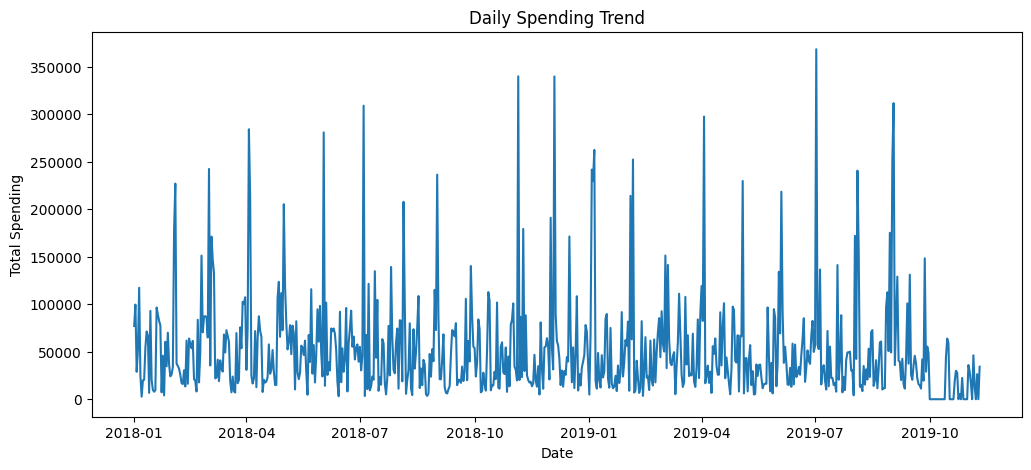

In [20]:
#Daily Trend
plt.figure(figsize=(12,5))

plt.plot(
    daily_spending["date"],
    daily_spending["total_spending"]
)

plt.title("Daily Spending Trend")

plt.xlabel("Date")

plt.ylabel("Total Spending")

plt.show()

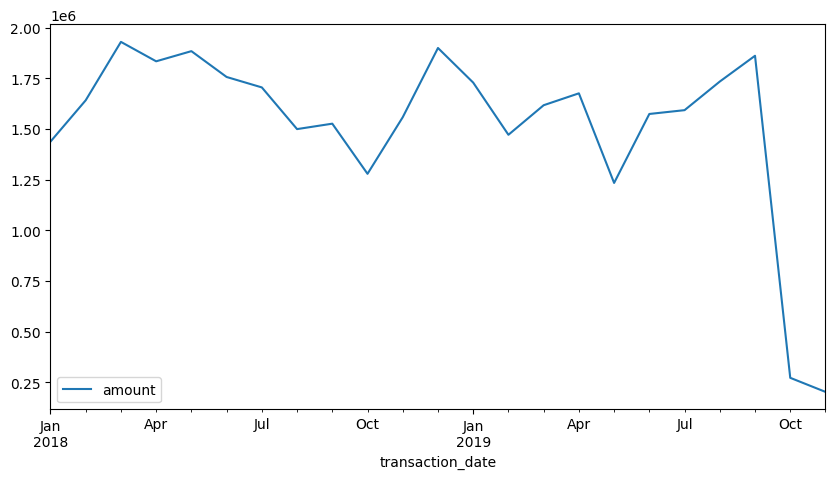

In [21]:
#Monthly Spending
monthly_spending.plot(
    x="transaction_date",
    y="amount",
    figsize=(10,5)
)

plt.show()

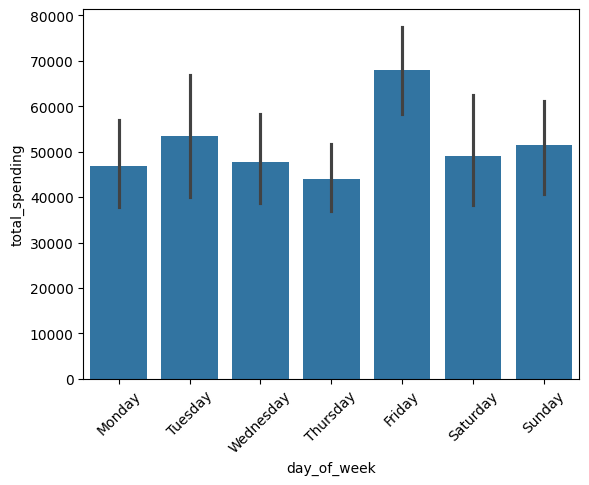

In [22]:
#Day of Week Analysis
daily_spending["day_of_week"] = daily_spending["date"].dt.day_name()
daily_spending.groupby(
    "day_of_week"
)["total_spending"].mean()

sns.barplot(
    x="day_of_week",
    y="total_spending",
    data=daily_spending
)

plt.xticks(rotation=45)

plt.show()

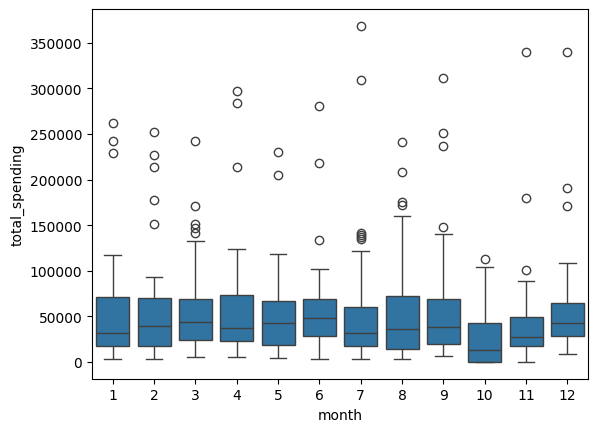

In [23]:
#Monthly Analysis
daily_spending["month"] = daily_spending["date"].dt.month
sns.boxplot(
    x="month",
    y="total_spending",
    data=daily_spending
)

plt.show()

In [24]:
#Autocorrelation
print(
    daily_spending["total_spending"].autocorr(lag=1)
)

print(
    daily_spending["total_spending"].autocorr(lag=7)
)

print(
    daily_spending["total_spending"].autocorr(lag=30)
)

0.17434725844750226
-0.021823010787288842
0.15012399011722113


## Calender Features

In [25]:
daily_spending["day"] = daily_spending["date"].dt.day

daily_spending["day_of_week"] = daily_spending["date"].dt.dayofweek

daily_spending["week"] = daily_spending["date"].dt.isocalendar().week

daily_spending["month"] = daily_spending["date"].dt.month

daily_spending["quarter"] = daily_spending["date"].dt.quarter

daily_spending["year"] = daily_spending["date"].dt.year

daily_spending["is_weekend"] = (
    daily_spending["day_of_week"] >= 5
).astype(int)

daily_spending["is_month_end"] = (
    daily_spending["date"].dt.is_month_end
).astype(int)

## Lag feature

In [26]:
#Lag 1

daily_spending["lag_1"] = (
    daily_spending["total_spending"].shift(1)
)

In [27]:
#Lag 7

daily_spending["lag_7"] = (
    daily_spending["total_spending"].shift(7)
)

In [28]:
#Lag 30

daily_spending["lag_30"] = (
    daily_spending["total_spending"].shift(30)  
)

In [29]:
#Rolling Mean

daily_spending["rolling_mean_7"] = (
    daily_spending["total_spending"]
    .shift(1)
    .rolling(7)
    .mean()
)

In [30]:
daily_spending["rolling_mean_30"] = (
    daily_spending["total_spending"]
    .shift(1)
    .rolling(30)
    .mean()
)

In [31]:
daily_spending = daily_spending.dropna()

In [32]:
daily_spending.to_csv(
    "D:/clg_project/AI-Financial-Wellness-Coach/data/processed/forecasting/forecast_features.csv",
    index=False
)

## Train Validation Test Split

In [33]:
n = len(daily_spending)

train_end = int(n*0.70)

val_end = int(n*0.85)

In [34]:
# Train
train = daily_spending.iloc[:train_end]

In [35]:
# validation
validation = daily_spending.iloc[train_end:val_end]

In [36]:
# Test
test = daily_spending.iloc[val_end:]

In [37]:
train = daily_spending.iloc[:train_end].copy()

validation = daily_spending.iloc[train_end:val_end].copy()

test = daily_spending.iloc[val_end:].copy()

## Baseline Model


In [38]:
test["prediction"] = test["lag_1"]

##Metrics

In [39]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

mae = mean_absolute_error(
    test["total_spending"],
    test["prediction"]
)

rmse = np.sqrt(
    mean_squared_error(
        test["total_spending"],
        test["prediction"]
    )
)

print(mae)

print(rmse)


32030.159591836735
55290.49323894321


## Machine learning models 

In [40]:
#Features

features = [
    "lag_1",
    "lag_7",
    "lag_30",
    "rolling_mean_7",
    "rolling_mean_30",
    "day_of_week",
    "month",
    "is_weekend",
    "is_month_end"
]

In [41]:
#target

target = "total_spending"

In [42]:
#Train Data

X_train = train[features]

y_train = train[target]

X_test = test[features]

y_test = test[target]

##Linear regression

In [43]:
from sklearn.linear_model import LinearRegression , Ridge , Lasso

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_prediction = lr.predict(X_test)

In [44]:
tscv = TimeSeriesSplit(n_splits=5)

## Ridge Regression

In [45]:
ridge_params = {
    "alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

from sklearn.linear_model import Ridge

ridge = Ridge()

ridge_grid = GridSearchCV(
    ridge,
    ridge_params,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("Best Parameters:", ridge_grid.best_params_)
print("Best R2:", ridge_grid.best_score_)

Best Parameters: {'alpha': 100}
Best R2: -0.06793233051712826


In [46]:
lasso_params = {
    "alpha": [0.001, 0.01, 0.1, 1, 10]
}

from sklearn.linear_model import Lasso

lasso = Lasso()

lasso_grid = GridSearchCV(
    lasso,
    lasso_params,
    cv=tscv,
    scoring="r2",
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

print(lasso_grid.best_params_)
print(lasso_grid.best_score_)

{'alpha': 10}
-0.2011290388830978


##Random Forest

In [47]:
from sklearn.ensemble import RandomForestRegressor

rf_params = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf = RandomForestRegressor(random_state=42)

rf_grid = GridSearchCV(
    rf,
    rf_params,
    cv=tscv,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

rf_grid.fit(X_train, y_train)

print("Best Parameters")
print(rf_grid.best_params_)

print("Best R2")
print(rf_grid.best_score_)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.0s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.2s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.1s
[CV] END max_depth=5, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=200; tot

[CV] END max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time=   5.1s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time=   2.4s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time=   2.8s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=300; total time=   2.1s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=500; total time=   7.1s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=500; total time=   2.2s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=500; total time=   2.1s
[CV] END max_depth=15, max_features=log2, min_samples_leaf=1, min_samples_split=5, n_estimators=500; total time=  10.2s
[CV] END max_depth=15, max_features=log2

##XGBoost

In [ ]:
from xgboost import XGBRegressor

xgb_params = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "gamma": [0, 0.1, 0.3],
    "min_child_weight": [1, 3, 5]
}

xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

xgb_grid = GridSearchCV(
    xgb,
    xgb_params,
    cv=tscv,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

xgb_grid.fit(X_train, y_train)

print("Best Parameters")
print(xgb_grid.best_params_)

print("Best R2")
print(xgb_grid.best_score_)

Fitting 5 folds for each of 1296 candidates, totalling 6480 fits
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_depth=3, min_child_weight=1, n_estimators=100, subsample=1.0; total time=   0.0s
[CV] END colsample_bytree=0.8, gamma=0, learning_rate=0.01, max_d

[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=7, min_child_weight=1, n_estimators=300, subsample=0.8; total time=   1.7s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=7, min_child_weight=1, n_estimators=300, subsample=0.8; total time=   0.5s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=7, min_child_weight=1, n_estimators=300, subsample=1.0; total time=   0.1s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=7, min_child_weight=1, n_estimators=300, subsample=1.0; total time=   0.2s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=7, min_child_weight=1, n_estimators=300, subsample=1.0; total time=   0.3s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=7, min_child_weight=1, n_estimators=300, subsample=1.0; total time=   0.4s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=7, min_child_weight=1, n_estimators=300, subsa

## Evaluate Model

In [ ]:
#rabdom forest
from sklearn.metrics import r2_score
mae = mean_absolute_error(
    y_test,
    rf_prediction
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_prediction
    )
)

r2 = r2_score(
    y_test,
    rf_prediction
)

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 :", r2)

MAE : 90760.09088979599
RMSE : 118770.80164476355
R2 : -4.414783574818032


In [ ]:
#linear regression
from sklearn.metrics import r2_score
mae = mean_absolute_error(
    y_test,
    lr_prediction
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_prediction
    )
)

r2 = r2_score(
    y_test,
    lr_prediction
)

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 :", r2)

MAE : 47638.95707303808
RMSE : 61231.66404346391
R2 : -0.4391758126451295


In [ ]:
#XG Boost
from sklearn.metrics import r2_score
mae = mean_absolute_error(
    y_test,
    xg_prediction
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xg_prediction
    )
)

r2 = r2_score(
    y_test,
    xg_prediction
)

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 :", r2)

MAE : 78408.29353555485
RMSE : 109001.89377010668
R2 : -3.5606822361736956


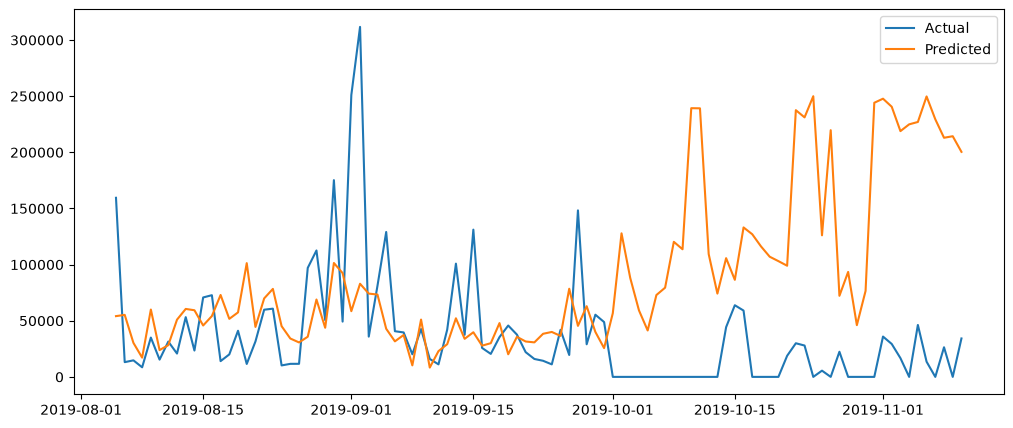

In [ ]:
#Actual vs Predicted

plt.figure(figsize=(12,5))

plt.plot(
    test["date"],
    y_test,
    label="Actual"
)

plt.plot(
    test["date"],
    rf_prediction,
    label="Predicted"
)

plt.legend()

plt.show()

In [ ]:
#Saving Model

import joblib

joblib.dump(
    rf,
    "models/forecasting/spending_forecaster.pkl"
)

FileNotFoundError: [Errno 2] No such file or directory: 'models/forecasting/spending_forecaster.pkl'